In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import pvlib
import pytz
from sklearn.metrics import r2_score
from tqdm import tqdm
# R-squared, MSE

/home/mateusz/miniconda3/envs/irr/lib/python3.10/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/mateusz/miniconda3/envs/irr/lib/python3.10/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/home/mateusz/miniconda3/envs/irr/lib/python3.10/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/mateusz/miniconda3/envs/irr/lib/python3.10/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


In [2]:
df = pd.read_csv("../data/Prepared/cleaned_irradiance.csv")

In [3]:
us_pacific = pytz.timezone("US/Pacific")
utc = pytz.utc


def calculate_sun_center_in_image(timestamp, image_shape, offset=165):
    date = pd.to_datetime(timestamp, format="%Y%m%d_%H%M%S")
    us_pacific_date = us_pacific.localize(date)
    utc_date = us_pacific_date.astimezone(utc).strftime("%Y%m%d_%H%M%S")

    solarposition = pvlib.solarposition.get_solarposition(
        time=pd.to_datetime(utc_date, format="%Y%m%d_%H%M%S"), latitude=38.642, longitude=-121.148
    )
    zenith = solarposition["zenith"][0]
    azimuth = solarposition["azimuth"][0]

    # compensation of camera orientation
    azimuth -= offset

    R = 2 * 0.48 * np.tan(np.deg2rad(zenith) / 2)

    x_sc = R * np.sin(np.deg2rad(azimuth))
    y_sc = R * np.cos(np.deg2rad(azimuth))

    # convert to the image plane
    x_scp = image_shape[1] / 2 + x_sc * image_shape[1] / 2
    y_scp = image_shape[0] / 2 + y_sc * image_shape[0] / 2

    return int(x_scp), int(y_scp)

In [4]:
timestamp = "20140816_170000"

img_rgb = np.asarray(Image.open(f"./20140816/{timestamp}.jpg")) / 255.0
img_grey = np.asarray(Image.open(f"./20140816/{timestamp}.jpg").convert("L")) / 255.0
img_hsv = np.asarray(Image.open(f"./20140816/{timestamp}.jpg").convert("HSV")) / 255.0

r = img_rgb[..., 0]
g = img_rgb[..., 1]
b = img_rgb[..., 2]

h = img_hsv[..., 0]
s = img_hsv[..., 1]
v = img_hsv[..., 2]
i = img_grey

In [5]:
# fig, ax = plt.subplots(2, 4, figsize=(8,16))

# ax[0][0].imshow(img_rgb)
# ax[0][1].imshow(r, cmap='gray', vmax=1, vmin=0)
# ax[0][2].imshow(g, cmap='gray', vmax=1, vmin=0)
# ax[0][3].imshow(b, cmap='gray', vmax=1, vmin=0)
# ax[1][0].imshow(h, cmap='gray', vmax=1, vmin=0)
# ax[1][1].imshow(s, cmap='gray', vmax=1, vmin=0)
# ax[1][2].imshow(v, cmap='gray', vmax=1, vmin=0)
# ax[1][3].imshow(i, cmap='gray', vmax=1, vmin=0)

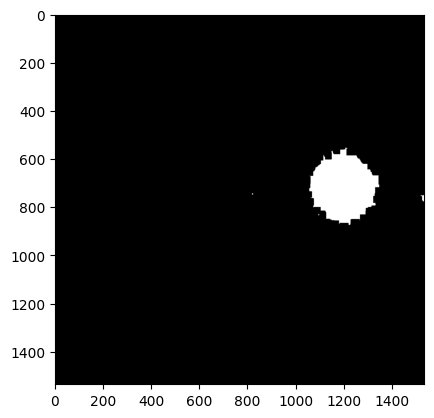

In [6]:
# based on https://www.sciencedirect.com/science/article/pii/S0960148116304529?via%3Dihub
F_s = np.uint8(((r + g + b + v + i) / 5 - (h + s) / 2) > 0.85)

F_s_closing = cv2.morphologyEx(F_s, cv2.MORPH_CLOSE, np.ones((9, 9), np.uint8), iterations=3)
plt.imshow(F_s_closing, cmap="gray", vmax=1)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


1196 719 1163 731


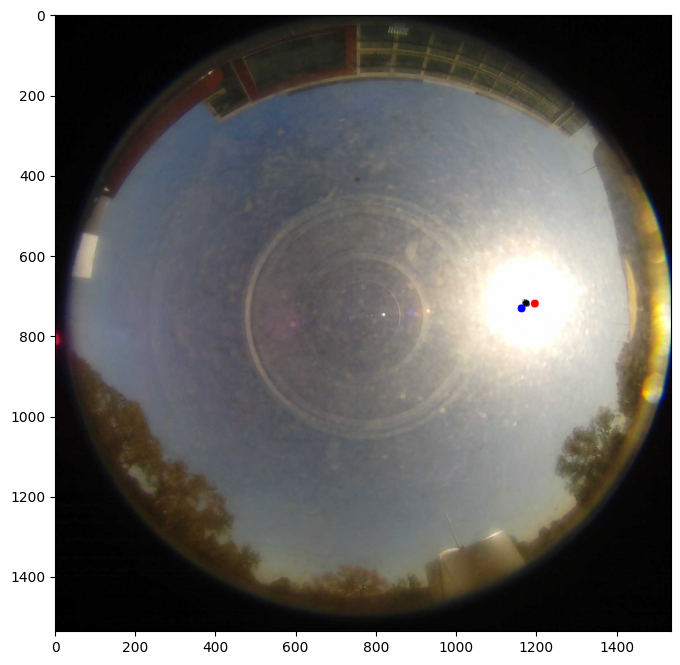

In [7]:
img_with_sun_center = img_rgb.copy()

contours, hierarchy = cv2.findContours(F_s_closing, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
max_cnt = sorted(contours, key=cv2.contourArea)[-1]

M = cv2.moments(max_cnt)
cX = int(M["m10"] / M["m00"])
cY = int(M["m01"] / M["m00"])

cv2.circle(img_with_sun_center, (cX, cY), 10, (255, 0, 0), -1)

sX, sY = calculate_sun_center_in_image(timestamp, (1536, 1536))
cv2.circle(img_with_sun_center, (sX, sY), 10, (0, 0, 255), -1)

print(cX, cY, sX, sY)

fig = plt.figure(figsize=(8, 8))
plt.imshow(img_with_sun_center)

In [8]:
data_path = "./"
irradiance_threshold = 200
img_list = list(
    filter(
        lambda x: df[df["image_name"] == x.name]["ghi"].values[0] > irradiance_threshold,
        sorted(Path(data_path).rglob("*.jpg")),
    )
)
print(len(img_list))

pred_x = []
pred_y = []
proper_img_list = []

for img_path in tqdm(img_list):
    timestamp = img_path.stem
    img_rgb = np.asarray(Image.open(img_path)) / 255.0
    img_grey = np.asarray(Image.open(img_path).convert("L")) / 255.0
    img_hsv = np.asarray(Image.open(img_path).convert("HSV")) / 255.0

    r = img_rgb[..., 0]
    g = img_rgb[..., 1]
    b = img_rgb[..., 2]

    h = img_hsv[..., 0]
    s = img_hsv[..., 1]
    v = img_hsv[..., 2]
    i = img_grey

    F_s = np.uint8(((r + g + b + v + i) / 5 - (h + s) / 2) > 0.85)

    F_s_closing = cv2.morphologyEx(F_s, cv2.MORPH_CLOSE, np.ones((9, 9), np.uint8), iterations=3)

    contours, hierarchy = cv2.findContours(F_s_closing, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) < 1:
        continue
    max_cnt = sorted(contours, key=cv2.contourArea)[-1]

    M = cv2.moments(max_cnt)
    cX = int(M["m10"] / M["m00"])
    cY = int(M["m01"] / M["m00"])
    pred_x.append(cX)
    pred_y.append(cY)
    proper_img_list.append(img_path)

# y_pred = (pred_x, pred_y)
y_pred = np.stack([pred_x, pred_y], axis=-1)
print(len(proper_img_list))

2630


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2630/2630 [04:12<00:00, 10.43it/s]

2630


In [16]:
min_angle = 0
max_angle = 360
angle_step = 30

patience = 5
iter_no_change = 0

r2 = 0.0
max_r2 = -np.inf

while iter_no_change < patience and angle_step > 0.05:
    pvlib_preds = []
    for angle in np.arange(min_angle, max_angle, angle_step):
        timestamp = img_path.stem
        _pvlib_x = []
        _pvlib_y = []
        for img_path in proper_img_list:
            timestamp = img_path.stem
            sX, sY = calculate_sun_center_in_image(timestamp, (1536, 1536), offset=angle)
            _pvlib_x.append(sX)
            _pvlib_y.append(sY)
        pvlib_preds.append(np.stack([_pvlib_x, _pvlib_y], axis=-1))

    _r2 = []
    for idx in range(len(pvlib_preds)):
        _r2_score = r2_score(pvlib_preds[idx], y_pred)
        _r2.append(_r2_score)

    r2 = max(_r2)
    best_angle_offset = min_angle + _r2.index(r2) * angle_step
    print(best_angle_offset, r2)
    if r2 > max_r2:
        max_r2 = r2
        iter_no_change = 0
    else:
        iter_no_change += 1

    min_angle = best_angle_offset - 2 * angle_step
    max_angle = best_angle_offset + 2 * angle_step
    angle_step /= 2

150 0.8330230357456843
165.0 0.9716120043106831
165.0 0.9716120043106831
165.0 0.9716120043106831
166.875 0.9726602505606468
165.9375 0.9734025289413321
166.40625 0.9734121742985069
166.171875 0.9735073415262838
166.171875 0.9735073415262838
166.171875 0.9735073415262838
166.171875 0.9735073415262838
166.1865234375 0.9735187278727515
166.1865234375 0.9735187278727515
166.175537109375 0.973526780170445
166.175537109375 0.973526780170445
166.17645263671875 0.9735294518385376
166.17645263671875 0.9735294518385376
166.17645263671875 0.9735294518385376


KeyboardInterrupt: 

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2630/2630 [00:04<00:00, 604.16it/s]


0.9716120043106831


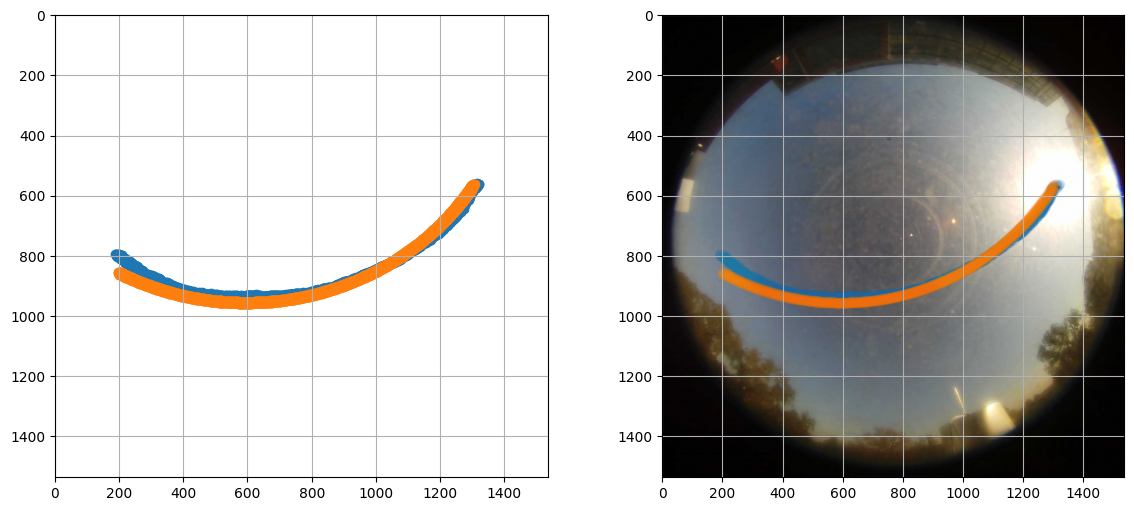

In [17]:
offset = 165
pvlib_x = []
pvlib_y = []

for img_path in tqdm(proper_img_list):
    timestamp = img_path.stem
    sX, sY = calculate_sun_center_in_image(timestamp, (1536, 1536), offset=offset)
    pvlib_x.append(sX)
    pvlib_y.append(sY)

print(r2_score(np.stack([pvlib_x, pvlib_y], axis=-1), y_pred))

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].scatter(x=pred_x, y=pred_y)
ax[0].scatter(x=pvlib_x, y=pvlib_y)
ax[0].set_xlim((0, 1536))
ax[0].set_ylim((1536, 0))
ax[0].grid(True)

ax[1].imshow(img_rgb)
ax[1].scatter(x=pred_x, y=pred_y, alpha=0.05)
ax[1].scatter(x=pvlib_x, y=pvlib_y, alpha=0.05)
ax[1].set_xlim((0, 1536))
ax[1].set_ylim((1536, 0))
ax[1].grid(True)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2630/2630 [00:04<00:00, 601.52it/s]


0.973526415870636


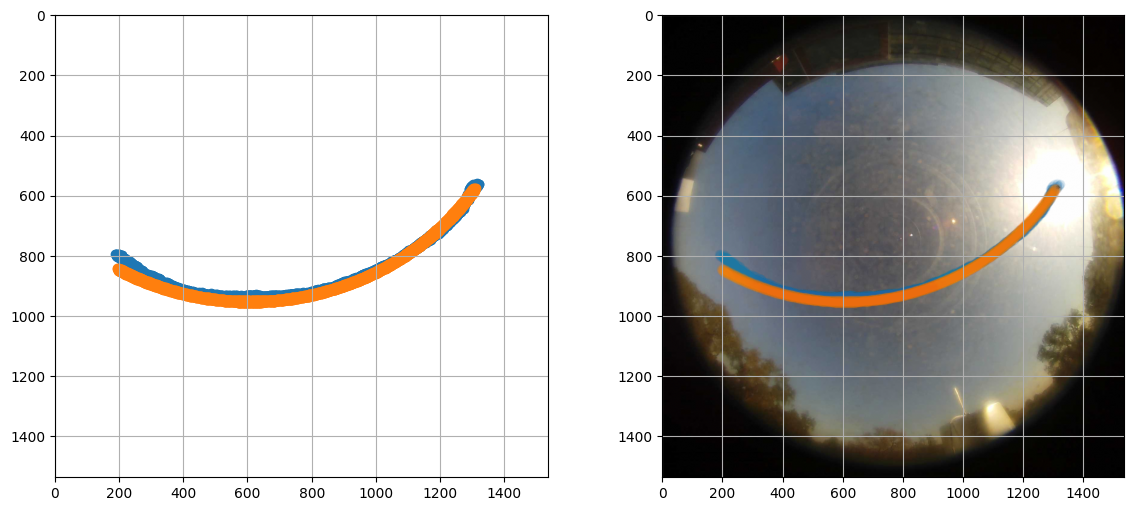

In [18]:
offset = 166.176
pvlib_x = []
pvlib_y = []

for img_path in tqdm(proper_img_list):
    timestamp = img_path.stem
    sX, sY = calculate_sun_center_in_image(timestamp, (1536, 1536), offset=offset)
    pvlib_x.append(sX)
    pvlib_y.append(sY)

print(r2_score(np.stack([pvlib_x, pvlib_y], axis=-1), y_pred))

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].scatter(x=pred_x, y=pred_y)
ax[0].scatter(x=pvlib_x, y=pvlib_y)
ax[0].set_xlim((0, 1536))
ax[0].set_ylim((1536, 0))
ax[0].grid(True)

ax[1].imshow(img_rgb)
ax[1].scatter(x=pred_x, y=pred_y, alpha=0.05)
ax[1].scatter(x=pvlib_x, y=pvlib_y, alpha=0.05)
ax[1].set_xlim((0, 1536))
ax[1].set_ylim((1536, 0))
ax[1].grid(True)